# The scale radius $r_s$ of the distance selection function

The mock pulsars are star particles accepted with probability $S_\odot(r_\odot) = e^{-r_\odot/r_s}$
(times the on-sky $S(\delta)$, see `selection.py`). This notebook derives $r_s$ from the
catalog sample defined in `catalog.py` (47 pulsars: Donlon+2025 minus the duplicate
J0737$-$3039B and the five pulsars with $\sigma_d/d>1$).

**Model.** If the tracers were spread uniformly around the Sun, the number in a shell
$[r, r+dr]$ would grow as $r^2\,dr$. Multiplying by $S_\odot$ gives

$$p(r) \propto r^2 e^{-r/r_s},$$

a Gamma distribution with shape $\alpha=3$ and scale $\theta=r_s$. With $\alpha$ fixed, the
maximum-likelihood estimate is $\hat r_s = \bar r/3$, and the Fisher information gives
$\sigma(\hat r_s) = \hat r_s/\sqrt{3N}$.

The notebook then checks the two assumptions: that $\alpha=3$, and that the simulated
old-star density is locally uniform.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats

HERE = Path.cwd()                       # run from clean_experiments/mock_catalog
sys.path.insert(0, str(HERE.parent))
from mock_catalog.catalog import load_catalog, radial_scale
from mock_catalog.candidates import OBSERVER, load_candidates
from mock_catalog.selection import SkySelection, acceptance

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except ImportError:
    pass

cat = load_catalog()
d = cat["d_kpc"]
N = d.size
print(f"{N} pulsars; excluded: {', '.join(cat['excluded'])}")
print(f"heliocentric distance [kpc]: mean {d.mean():.3f}, median {np.median(d):.3f}, max {d.max():.2f}")

47 pulsars; excluded: J0737-3039B, J1721-2457, J1946+3417, J2229+2643, J2302+4442, J2322-2650
heliocentric distance [kpc]: mean 1.421, median 1.170, max 4.17


## 1. Gamma(3, $r_s$) fit

In [2]:
r_s = d.mean() / 3
sigma_fisher = r_s / np.sqrt(3 * N)
boot = np.random.default_rng(0).choice(d, size=(20000, N)).mean(axis=1) / 3
assert r_s == radial_scale(cat)            # the value catalog.py hands to the mocks

print(f"r_s = mean / 3 = {r_s:.4f} kpc")
print(f"  Fisher error    {sigma_fisher:.4f} kpc")
print(f"  bootstrap error {boot.std():.4f} kpc (resampling the {N} distances)")

r_s = mean / 3 = 0.4738 kpc
  Fisher error    0.0399 kpc
  bootstrap error 0.0439 kpc (resampling the 47 distances)


## 2. Is $\alpha = 3$ supported?

Fit shape and scale together, compare the likelihoods (one extra parameter, so
$2\Delta\ln L \sim \chi^2_1$), and run a Kolmogorov–Smirnov test of the fixed-$\alpha$ model.
The KS $p$-value is conservative here because $r_s$ was estimated from the same data.

In [3]:
alpha_free, _, theta_free = stats.gamma.fit(d, floc=0)
ll_3 = stats.gamma.logpdf(d, 3, scale=r_s).sum()
ll_free = stats.gamma.logpdf(d, alpha_free, scale=theta_free).sum()
lr = 2 * (ll_free - ll_3)
ks = stats.kstest(d, "gamma", args=(3, 0, r_s))

print(f"free fit: alpha = {alpha_free:.2f}, theta = {theta_free:.3f} kpc")
print(f"likelihood ratio 2 dlnL = {lr:.2f}  ->  p = {stats.chi2.sf(lr, 1):.2f}")
print(f"KS vs Gamma(3, r_s): D = {ks.statistic:.3f}, p = {ks.pvalue:.2f}")

free fit: alpha = 2.48, theta = 0.573 kpc
likelihood ratio 2 dlnL = 1.02  ->  p = 0.31
KS vs Gamma(3, r_s): D = 0.083, p = 0.87


## 3. Truncation

The mock candidates stop at 5 kpc from the observer. The Gamma model puts almost no
probability beyond that, so the truncation needs no correction.

In [4]:
print(f"P(r > 5 kpc | Gamma(3, r_s)) = {stats.gamma.sf(5.0, 3, scale=r_s):.4f}")
print(f"catalog pulsars beyond 5 kpc: {int(np.sum(d > 5))}")

P(r > 5 kpc | Gamma(3, r_s)) = 0.0018
catalog pulsars beyond 5 kpc: 0


## 4. Check against the simulated old-star density

The $r^2$ law assumes a uniform tracer density around the observer. With the actual m12i
old stars as candidates $c$ (positions $r_c$, declinations $\delta_c$), the likelihood of
the catalog distances under the target $n_*(\mathbf{x})\,S_\odot(r)\,S(\delta)$ gives

$$-\ln L(r_s) = \sum_i \frac{r_i}{r_s} + N \ln \sum_c S(\delta_c)\, e^{-r_c/r_s} + \text{const},$$

since $n_*(\mathbf{x}_i)$ and $S(\delta_i)$ do not depend on $r_s$. Its minimum makes the
mock's mean distance equal the catalog's.

In [5]:
c = load_candidates()
sky = SkySelection.from_catalog(cat)
acc = acceptance(c["x"], OBSERVER, 1.0, sky)          # r, l, b, dec of the candidates
r_c, S_delta = acc["r"], sky.S(acc["dec"])

def fit_rs(weights):
    nll = lambda rs: d.sum() / rs + N * np.log(np.sum(weights * np.exp(-r_c / rs)))
    res = optimize.minimize_scalar(nll, bounds=(0.1, 2.0), method="bounded")
    h = 1e-4
    curvature = (nll(res.x + h) - 2 * nll(res.x) + nll(res.x - h)) / h**2
    return res.x, 1 / np.sqrt(curvature)

rs_m12i_r, err_r = fit_rs(np.ones_like(r_c))
rs_m12i, err = fit_rs(S_delta)
print(f"{r_c.size:,} candidates (old stars within 5 kpc)")
print(f"m12i density, S_r only       : r_s = {rs_m12i_r:.3f} +- {err_r:.3f} kpc")
print(f"m12i density, S_r x S_delta  : r_s = {rs_m12i:.3f} +- {err:.3f} kpc")
print(f"Gamma(3) closed form         : r_s = {r_s:.3f} +- {sigma_fisher:.3f} kpc")
print(f"difference: {(rs_m12i - r_s) / np.hypot(err, sigma_fisher):.1f} sigma")

574,825 candidates (old stars within 5 kpc)
m12i density, S_r only       : r_s = 0.522 +- 0.048 kpc
m12i density, S_r x S_delta  : r_s = 0.525 +- 0.049 kpc
Gamma(3) closed form         : r_s = 0.474 +- 0.040 kpc
difference: 0.8 sigma


## 5. Figure

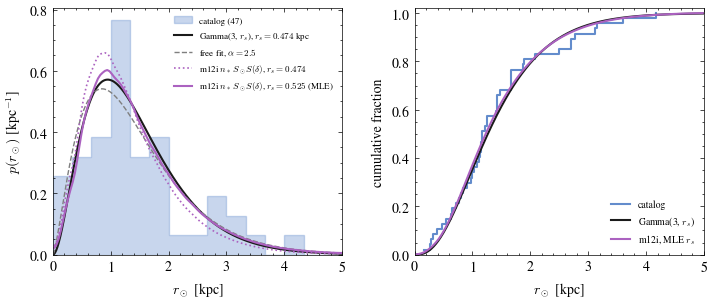

In [6]:
C_CAT, C_M12I, C_INK, C_REF = "#638ccc", "#ab62c0", "#1a1a1a", "#7f7f7f"
rg = np.linspace(0, 5, 500)
from scipy.ndimage import gaussian_filter1d
hist_c, edges = np.histogram(r_c, bins=125, range=(0, 5), weights=S_delta)
mid = 0.5 * (edges[1:] + edges[:-1])

def m12i_pdf(rs):
    q = gaussian_filter1d(hist_c * np.exp(-mid / rs), 1.5)       # 0.04-kpc bins, light smoothing
    return q / (q.sum() * (edges[1] - edges[0]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.4, 3.2), gridspec_kw=dict(wspace=0.25))
ax1.hist(d, bins=np.linspace(0, 5, 16), density=True, histtype="stepfilled", alpha=0.35,
         color=C_CAT, edgecolor=C_CAT, label=f"catalog ({N})")
ax1.plot(rg, stats.gamma.pdf(rg, 3, scale=r_s), color=C_INK, lw=1.5,
         label=rf"Gamma(3, $r_s$), $r_s={r_s:.3f}$ kpc")
ax1.plot(rg, stats.gamma.pdf(rg, alpha_free, scale=theta_free), color=C_REF, lw=1.0, ls="--",
         label=rf"free fit, $\alpha={alpha_free:.1f}$")
ax1.plot(mid, m12i_pdf(r_s), color=C_M12I, lw=1.2, ls=":",
         label=rf"m12i $n_*\,S_\odot S(\delta)$, $r_s={r_s:.3f}$")
ax1.plot(mid, m12i_pdf(rs_m12i), color=C_M12I, lw=1.5,
         label=rf"m12i $n_*\,S_\odot S(\delta)$, $r_s={rs_m12i:.3f}$ (MLE)")
ax1.set_xlim(0, 5); ax1.set_xlabel(r"$r_\odot$ [kpc]"); ax1.set_ylabel(r"$p(r_\odot)$ [kpc$^{-1}$]")
ax1.legend(frameon=False, fontsize=6.5)

ds = np.sort(d)
ax2.step(ds, np.arange(1, N + 1) / N, where="post", color=C_CAT, lw=1.5, label="catalog")
ax2.plot(rg, stats.gamma.cdf(rg, 3, scale=r_s), color=C_INK, lw=1.5, label="Gamma(3, $r_s$)")
ax2.plot(mid, np.cumsum(m12i_pdf(rs_m12i)) * (edges[1] - edges[0]), color=C_M12I, lw=1.5,
         label="m12i, MLE $r_s$")
ax2.set_xlim(0, 5); ax2.set_ylim(0, 1.02)
ax2.set_xlabel(r"$r_\odot$ [kpc]"); ax2.set_ylabel("cumulative fraction")
ax2.legend(frameon=False, fontsize=7, loc="lower right")
out = HERE / "figs"
out.mkdir(exist_ok=True)
fig.savefig(out / "rs_gamma_fit.pdf", bbox_inches="tight")
fig.savefig(out / "rs_gamma_fit.png", dpi=170, bbox_inches="tight")
plt.show()

## Result

- **$r_s = 0.474 \pm 0.040$ kpc** from the Gamma(3) fit; this is the value `catalog.py`
  gives the mocks.
- $\alpha=3$ is consistent with the data: the free fit prefers $\alpha\approx2.5$, but the
  likelihood gain is not significant ($p\approx0.3$), and the KS test finds no tension.
- The 5-kpc truncation of the candidates is negligible.
- Using the simulated old-star density instead of the uniform-density assumption gives
  $r_s \approx 0.52 \pm 0.05$ kpc, $0.8\sigma$ higher: the m12i old stars thin out
  faster than $r^2$ with distance (they are a disk), so a slightly larger $r_s$ is needed to
  reach the catalog's mean distance. The two values agree within their errors; we keep the
  simulation-independent Gamma value.